=== Task 2A: varying coupling strength K with sigma = 1 ===


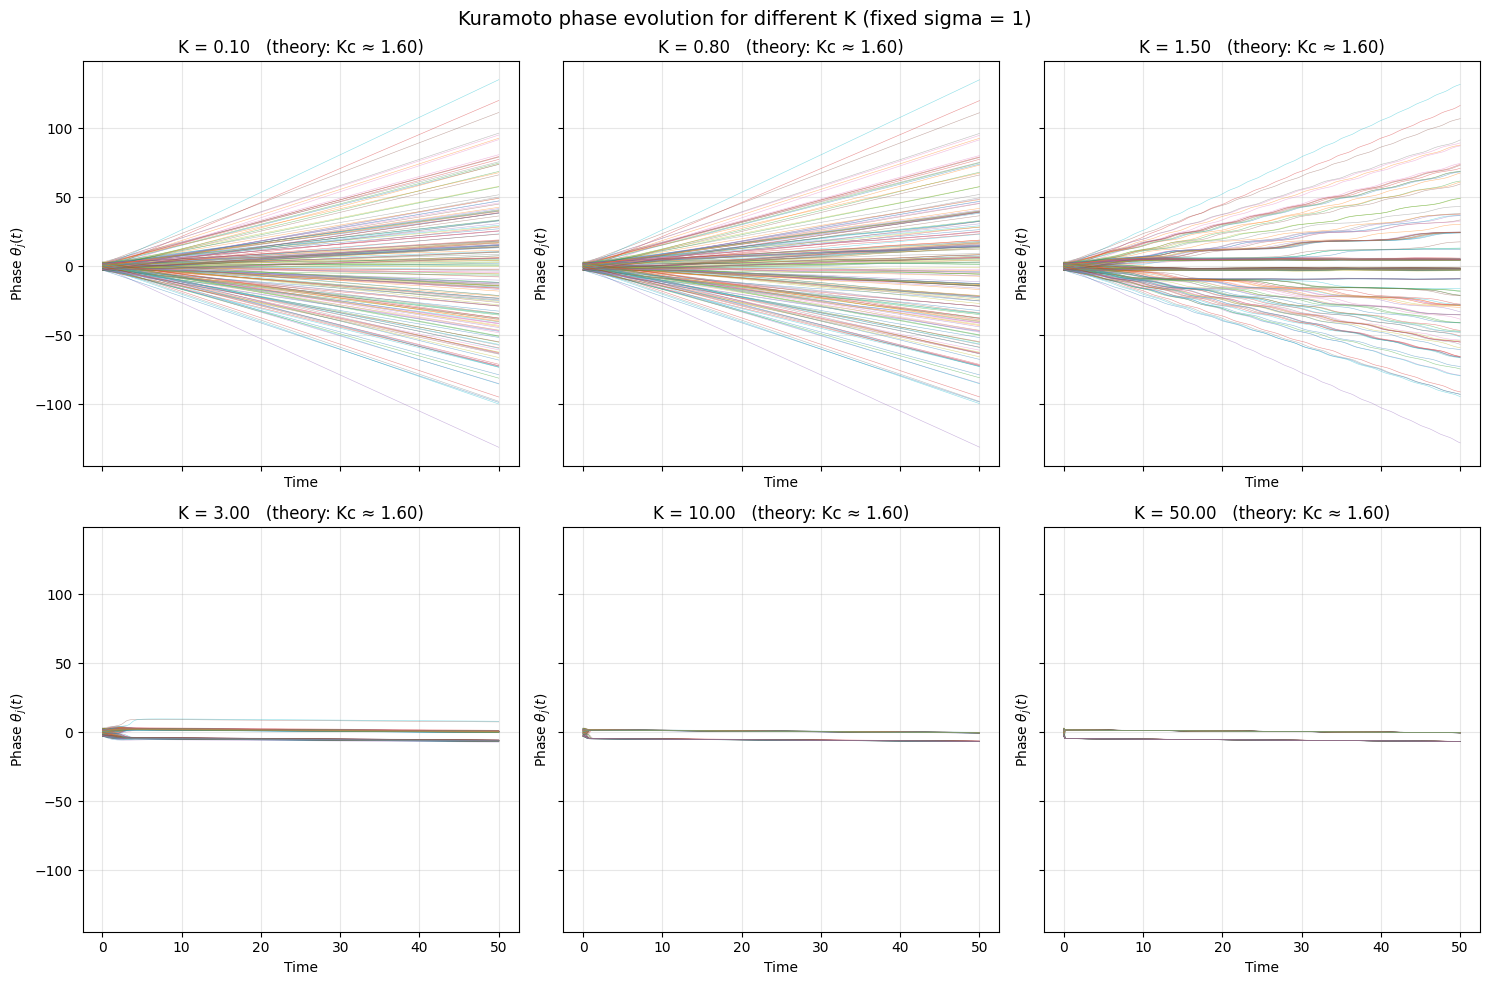

=== Task 2B: varying frequency spread sigma with K = 1.5 ===


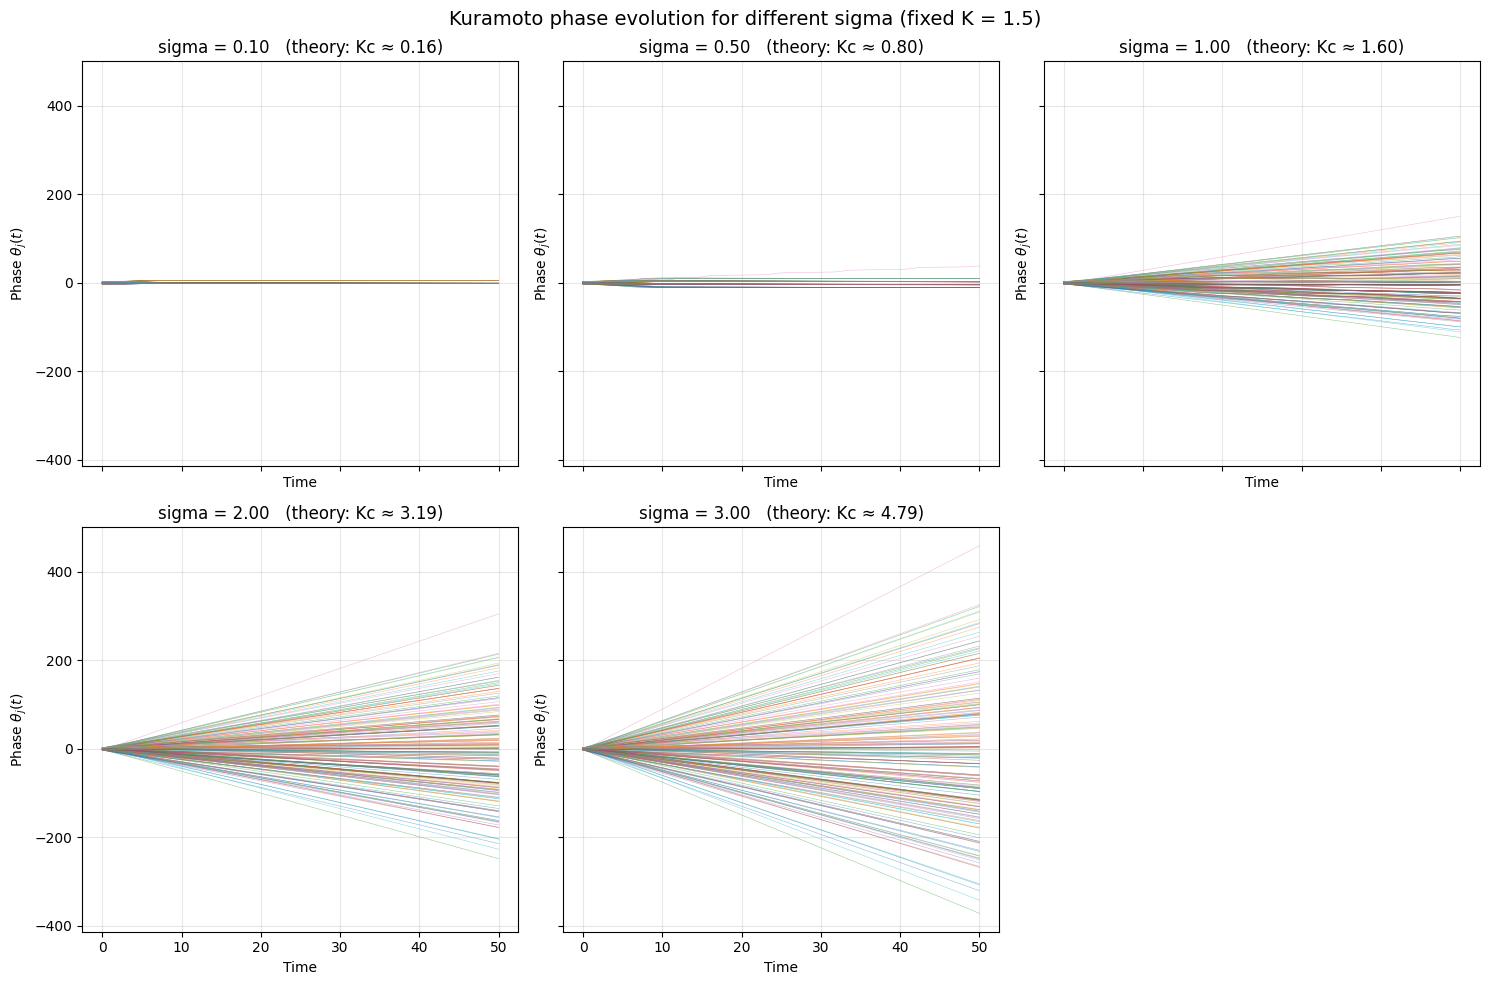

=== Task 3: order parameter dynamics ===


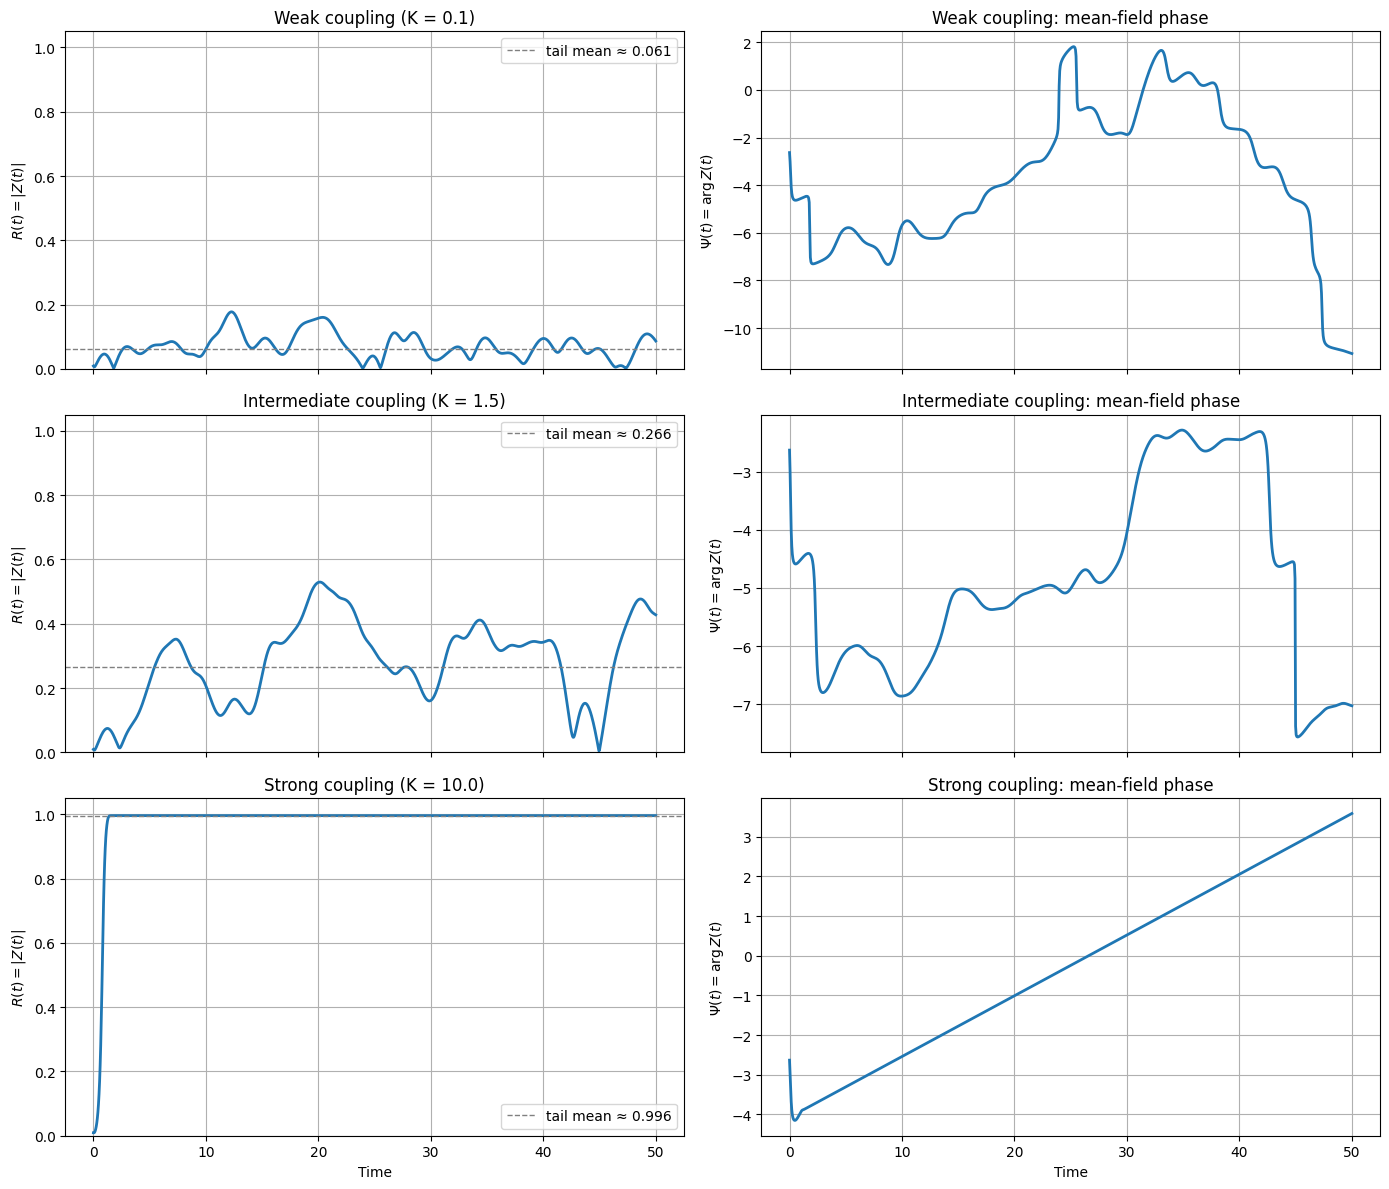

=== Task 3(i): unit-circle visualization ===


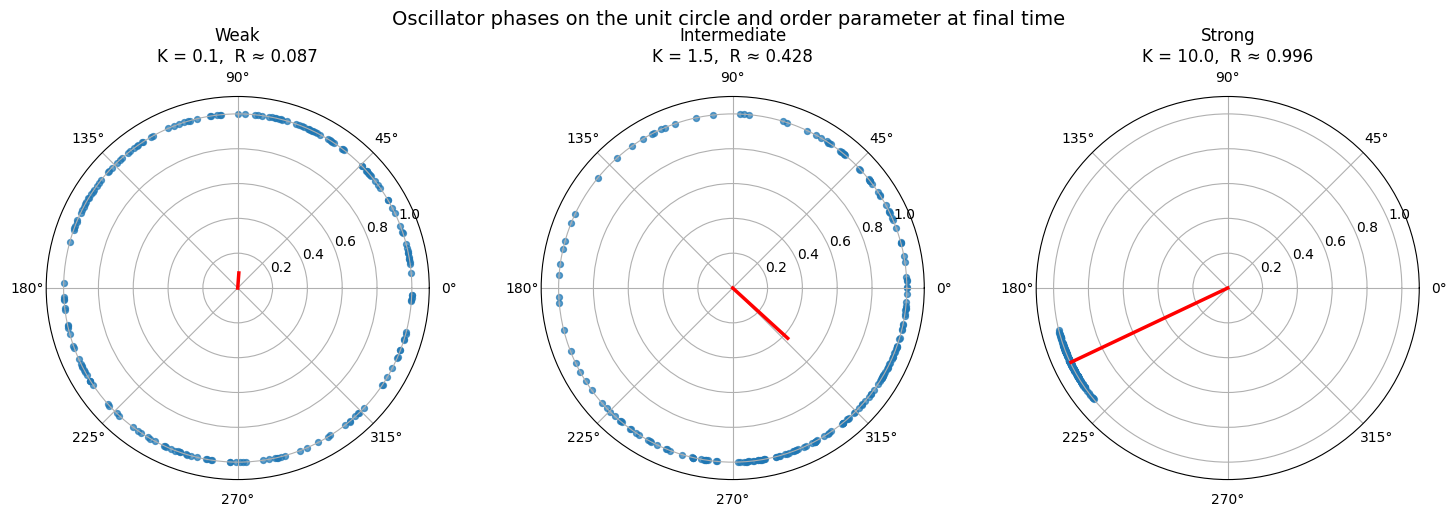

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# -------------------------------------------------------------------
# Kuramoto model: finite-N numerical study

# -------------------------------------------------------------------

plt.rcParams["figure.figsize"] = (12, 8)
np.random.seed(42)

# ----------------------------- Parameters ----------------------------
N = 200                 # number of oscillators
T = 50.0                # final simulation time
n_time = 1000           # number of output time points
t_eval = np.linspace(0.0, T, n_time)

# -------------------------------------------------------------------
# Core model functions
# -------------------------------------------------------------------

def kuramoto_rhs(t, theta, omega, K):
    """
    Right-hand side of the Kuramoto model

        d theta_i / dt = omega_i + (K/N) * sum_j sin(theta_j - theta_i)

    Parameters
    ----------
    t : float
        Time (not explicitly used, but required by solve_ivp).
    theta : ndarray, shape (N,)
        Current oscillator phases.
    omega : ndarray, shape (N,)
        Natural frequencies.
    K : float
        Coupling strength.

    Returns
    -------
    dtheta : ndarray, shape (N,)
        Time derivative of the phases.
    """
    phase_diff = theta[np.newaxis, :] - theta[:, np.newaxis]
    coupling = np.sum(np.sin(phase_diff), axis=1)
    dtheta = omega + (K / len(theta)) * coupling
    return dtheta


def simulate_kuramoto(theta0, omega, K, T, t_eval, rtol=1e-6, atol=1e-8):
    """
    Integrate the Kuramoto model for given initial phases, frequencies, and coupling.
    """
    sol = solve_ivp(
        kuramoto_rhs,
        (0.0, T),
        theta0,
        args=(omega, K),
        t_eval=t_eval,
        method="RK45",
        rtol=rtol,
        atol=atol
    )
    return sol


def compute_order_parameter(theta):
    """
    Compute the Kuramoto order parameter

        Z(t) = (1/N) sum_j exp(i theta_j(t)) = R(t) exp(i Psi(t))

    Parameters
    ----------
    theta : ndarray, shape (N, n_time)
        Phase trajectories.

    Returns
    -------
    R : ndarray, shape (n_time,)
        Coherence magnitude.
    Psi : ndarray, shape (n_time,)
        Mean-field phase.
    Z : ndarray, shape (n_time,)
        Complex order parameter.
    """
    Z = np.mean(np.exp(1j * theta), axis=0)
    R = np.abs(Z)
    Psi = np.angle(Z)
    return R, Psi, Z


def wrap_to_pi(theta):
    """
    Wrap phase values to the interval [-pi, pi).
    """
    return (theta + np.pi) % (2 * np.pi) - np.pi


def gaussian_kc_theory(sigma):
    """
    Infinite-N Kuramoto threshold for Gaussian frequency distribution
    with standard deviation sigma:

        K_c = 2 / (pi g(0)),
        g(0) = 1 / (sigma sqrt(2 pi))

    Hence:
        K_c = sigma * sqrt(8 / pi)
    """
    return sigma * np.sqrt(8 / np.pi)


# -------------------------------------------------------------------
# Shared random data for fair comparisons
# -------------------------------------------------------------------

sigma_ref = 1.0
omega_ref = np.random.normal(0.0, sigma_ref, N)
theta0_ref = np.random.uniform(-np.pi, np.pi, N)

# -------------------------------------------------------------------
# Task 2A: vary K with fixed sigma = 1
# -------------------------------------------------------------------

print("=== Task 2A: varying coupling strength K with sigma = 1 ===")

K_values = [0.1, 0.8, 1.5, 3.0, 10.0, 50.0]
Kc_ref = gaussian_kc_theory(sigma_ref)

fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)

for ax, K in zip(axes.flat, K_values):
    sol = simulate_kuramoto(theta0_ref, omega_ref, K, T, t_eval)
    theta = sol.y

    for j in range(N):
        ax.plot(sol.t, theta[j], lw=0.4, alpha=0.5)

    ax.set_title(f"K = {K:.2f}   (theory: Kc ≈ {Kc_ref:.2f})")
    ax.set_xlabel("Time")
    ax.set_ylabel(r"Phase $\theta_j(t)$")
    ax.grid(True, alpha=0.3)

fig.suptitle("Kuramoto phase evolution for different K (fixed sigma = 1)", fontsize=14)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Task 2B: vary sigma with fixed K
# -------------------------------------------------------------------

print("=== Task 2B: varying frequency spread sigma with K = 1.5 ===")

K_fixed = 1.5
sigma_values = [0.1, 0.5, 1.0, 2.0, 3.0]

# Use one standard-normal sample and scale it by sigma for fair comparison
base_omega = np.random.normal(0.0, 1.0, N)
theta0_sigma = np.random.uniform(-np.pi, np.pi, N)

fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)

for ax, sigma in zip(axes.flat, sigma_values):
    omega_sigma = sigma * base_omega
    Kc_sigma = gaussian_kc_theory(sigma)

    sol = simulate_kuramoto(theta0_sigma, omega_sigma, K_fixed, T, t_eval)
    theta = sol.y

    for j in range(N):
        ax.plot(sol.t, theta[j], lw=0.4, alpha=0.5)

    ax.set_title(f"sigma = {sigma:.2f}   (theory: Kc ≈ {Kc_sigma:.2f})")
    ax.set_xlabel("Time")
    ax.set_ylabel(r"Phase $\theta_j(t)$")
    ax.grid(True, alpha=0.3)

# Hide the unused 6th panel
axes.flat[-1].axis("off")

fig.suptitle("Kuramoto phase evolution for different sigma (fixed K = 1.5)", fontsize=14)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Task 3: order parameter dynamics
# -------------------------------------------------------------------

print("=== Task 3: order parameter dynamics ===")

regimes = {
    "Weak": 0.1,
    "Intermediate": 1.5,
    "Strong": 10.0
}

omega_task3 = np.random.normal(0.0, 1.0, N)
theta0_task3 = np.random.uniform(-np.pi, np.pi, N)

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)

for i, (label, K) in enumerate(regimes.items()):
    sol = simulate_kuramoto(theta0_task3, omega_task3, K, T, t_eval)
    theta = sol.y
    R, Psi, Z = compute_order_parameter(theta)

    # Order parameter magnitude
    axes[i, 0].plot(sol.t, R, lw=2)
    tail_mean = np.mean(R[-200:])
    axes[i, 0].axhline(tail_mean, color="gray", ls="--", lw=1,
                       label=f"tail mean ≈ {tail_mean:.3f}")
    axes[i, 0].set_ylim(0, 1.05)
    axes[i, 0].set_ylabel(r"$R(t)=|Z(t)|$")
    axes[i, 0].set_title(f"{label} coupling (K = {K})")
    axes[i, 0].grid(True)
    axes[i, 0].legend()

    # Mean phase
    axes[i, 1].plot(sol.t, np.unwrap(Psi), lw=2)
    axes[i, 1].set_ylabel(r"$\Psi(t)=\arg Z(t)$")
    axes[i, 1].set_title(f"{label} coupling: mean-field phase")
    axes[i, 1].grid(True)

axes[-1, 0].set_xlabel("Time")
axes[-1, 1].set_xlabel("Time")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Task 3(i): phases on the unit circle at final time
# -------------------------------------------------------------------

print("=== Task 3(i): unit-circle visualization ===")

fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={"projection": "polar"})

for ax, (label, K) in zip(axes, regimes.items()):
    sol = simulate_kuramoto(theta0_task3, omega_task3, K, T, t_eval)
    theta_final = wrap_to_pi(sol.y[:, -1])

    ax.scatter(theta_final, np.ones_like(theta_final), s=18, alpha=0.7)

    Z_final = np.mean(np.exp(1j * theta_final))
    R_final = np.abs(Z_final)
    Psi_final = np.angle(Z_final)

    ax.plot([Psi_final, Psi_final], [0, R_final], color="red", lw=2.5)

    ax.set_title(f"{label}\nK = {K},  R ≈ {R_final:.3f}")
    ax.set_ylim(0, 1.1)

plt.suptitle("Oscillator phases on the unit circle and order parameter at final time", fontsize=14)
plt.tight_layout()
plt.show()